First 5 Rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Dataset Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Freq

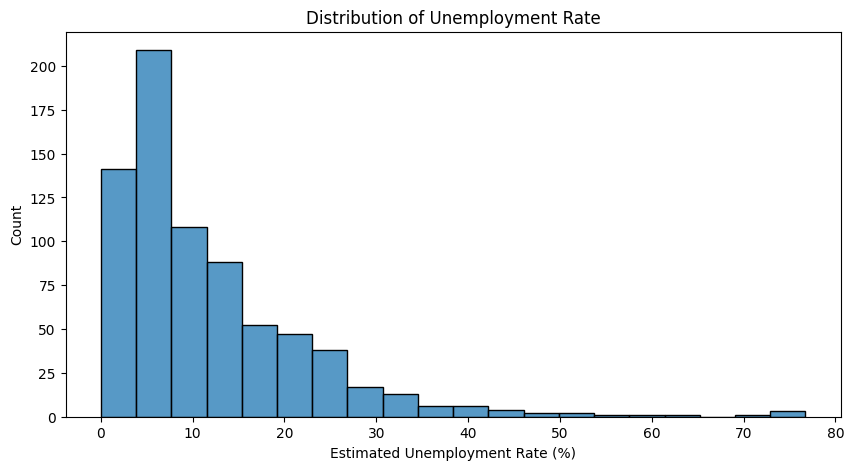

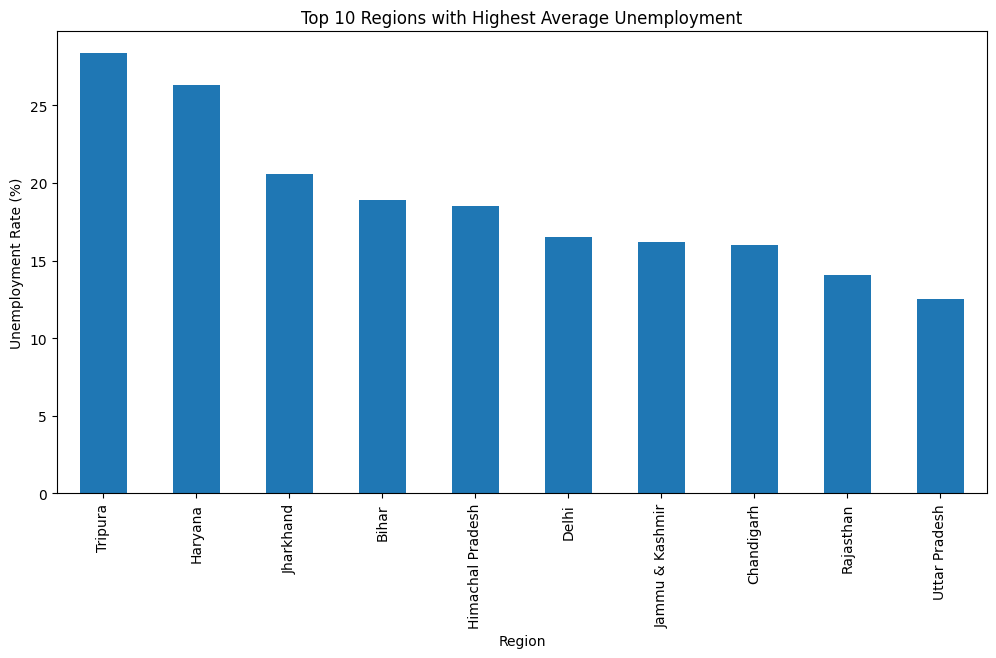

/tmp/ipykernel_1241/876631168.py:55: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


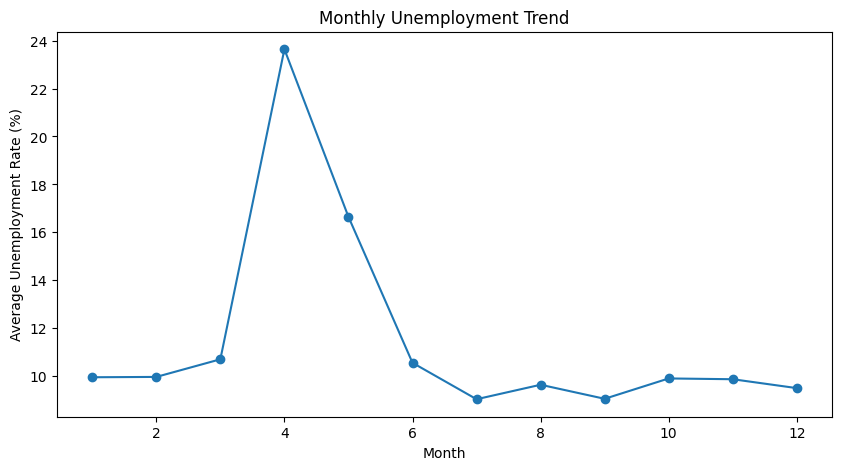

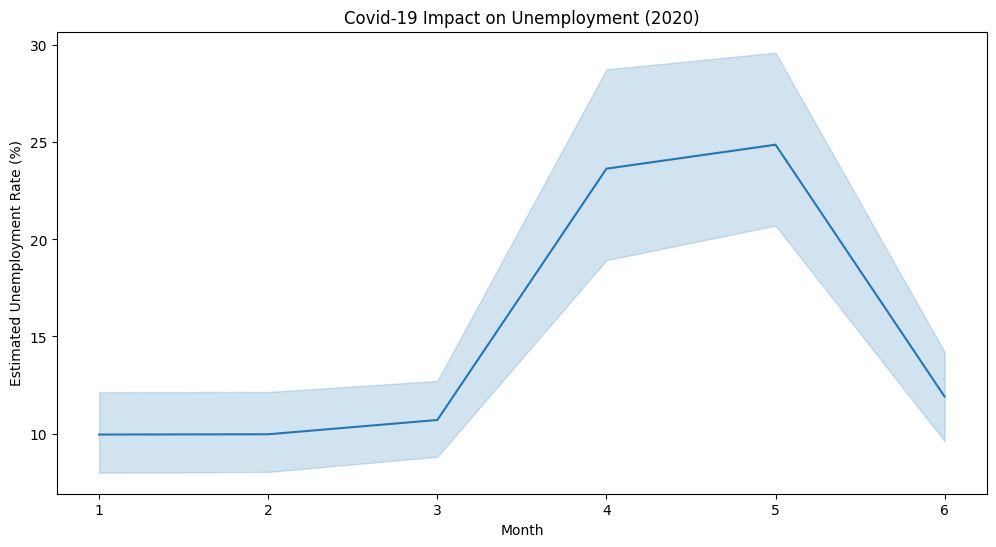

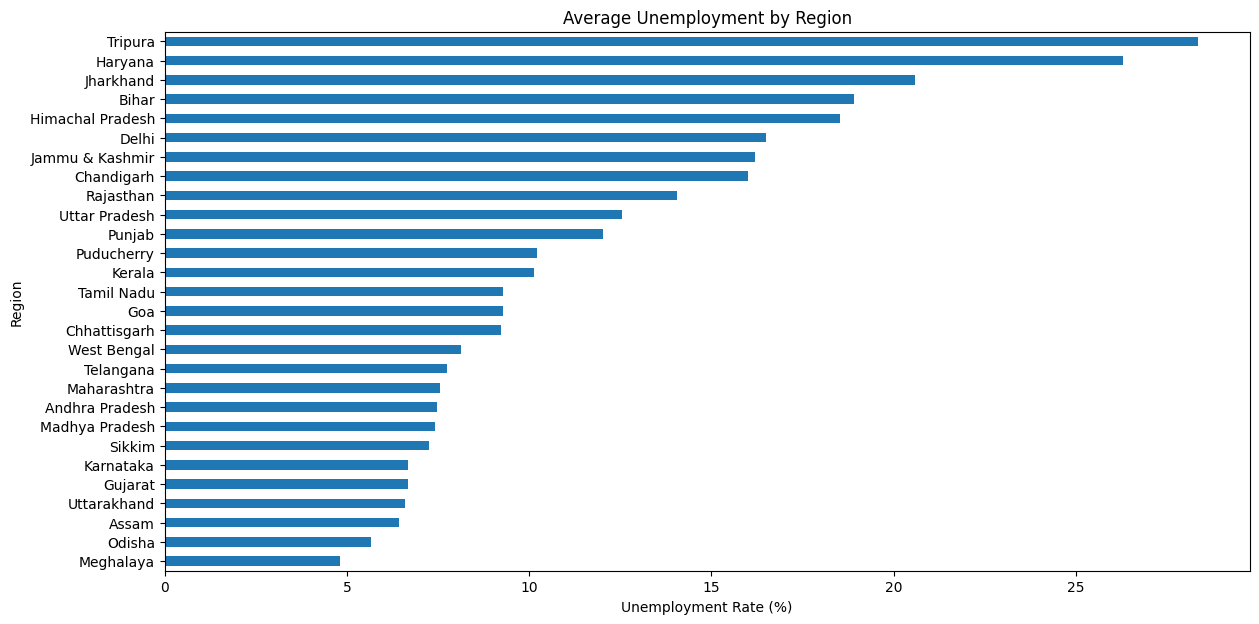

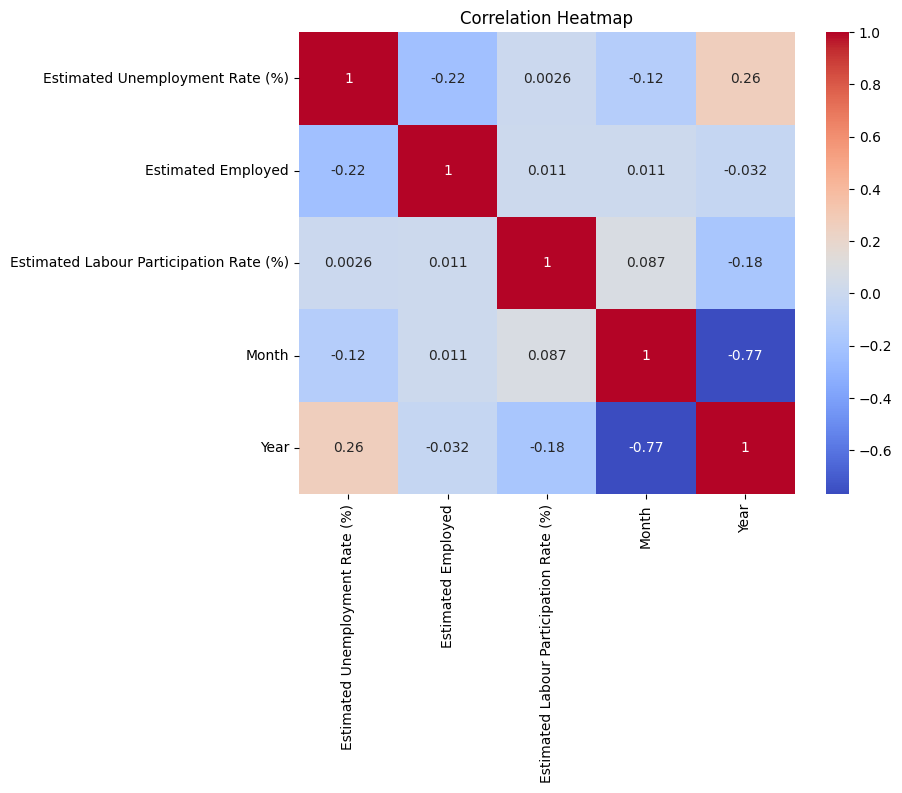


KEY FINDINGS
1. Unemployment rates increased significantly during Covid-19 in 2020.
2. Some regions consistently recorded higher unemployment rates.
3. Monthly trends indicate seasonal fluctuations.
4. Workforce participation and unemployment rate show noticeable relationships.
5. Policy interventions can help reduce unemployment spikes during economic disruptions.

CONCLUSION
This project analyzed unemployment trends in India using Python. Data cleaning, visualization, and exploratory analysis revealed significant increases in unemployment during the Covid-19 period. The findings can help policymakers design employment support programs and improve economic resilience during future crises.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/content/Unemployment in India.csv')

# Display First 5 Rows
print("First 5 Rows:")
print(df.head())

# Dataset Information
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Data Cleaning
df.columns = df.columns.str.strip()
df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Basic Statistics
print("\nStatistical Summary:")
print(df.describe())

# Region Information
print("\nRegions:")
print(df['Region'].unique())
print("\nNumber of Regions:", df['Region'].nunique())

# Unemployment Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20)
plt.title("Distribution of Unemployment Rate")
plt.show()

# Top 10 Regions by Average Unemployment
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
top10 = state_unemployment.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar')
plt.title("Top 10 Regions with Highest Average Unemployment")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# Date Processing
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Monthly Trend
monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')
plt.title("Monthly Unemployment Trend")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

# Covid-19 Impact Analysis
covid_data = df[df['Year'] == 2020]

plt.figure(figsize=(12,6))
sns.lineplot(
    x='Month',
    y='Estimated Unemployment Rate (%)',
    data=covid_data
)
plt.title("Covid-19 Impact on Unemployment (2020)")
plt.show()

# Regional Analysis
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14,7))
region_avg.sort_values().plot(kind='barh')
plt.title("Average Unemployment by Region")
plt.xlabel("Unemployment Rate (%)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# Insights
print("\nKEY FINDINGS")
print("1. Unemployment rates increased significantly during Covid-19 in 2020.")
print("2. Some regions consistently recorded higher unemployment rates.")
print("3. Monthly trends indicate seasonal fluctuations.")
print("4. Workforce participation and unemployment rate show noticeable relationships.")
print("5. Policy interventions can help reduce unemployment spikes during economic disruptions.")

print("\nCONCLUSION")
print("This project analyzed unemployment trends in India using Python. Data cleaning, visualization, and exploratory analysis revealed significant increases in unemployment during the Covid-19 period. The findings can help policymakers design employment support programs and improve economic resilience during future crises.")